<a href="https://colab.research.google.com/github/Kubojah-Dan/kuboja-codeboosters-2026/blob/main/DAY10/Day10_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Integration** **+** **Capstone**

In [25]:
!pip install pyspark groq sentence-transformers chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    Fo

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df = pd.read_csv("large_sales_data.csv")

print("=" * 60)
print("Sample Rows")
print("=" * 60)
print(df.head())
print()
print(df.describe())

Sample Rows
   order_id customer_name     product     category  quantity  unit_price  \
0      1001   Sneha Reddy     Monitor  Electronics        12       22000   
1      1002  Ramesh Kumar     Printer  Electronics        10       12000   
2      1003  Rahul Mishra       Mouse  Accessories        10         800   
3      1004    Suresh Rao      Tablet  Electronics         5       32000   
4      1005   Priya Patel  Headphones  Electronics         4        3500   

   revenue  order_date       city region    sales_rep    payment_method  \
0   264000  2023-05-21     Mumbai   West  Meera Patel               UPI   
1   120000  2023-08-05      Delhi  North  Anil Sharma       Credit Card   
2     8000  2023-01-14  Ahmedabad   West  Meera Patel  Cash on Delivery   
3   160000  2023-01-04      Surat   West   Ravi Kumar  Cash on Delivery   
4    14000  2023-06-22  Bangalore  South   Sunita Rao  Cash on Delivery   

  order_status  
0    Delivered  
1      Shipped  
2      Shipped  
3   Processi

In [12]:
import sqlite3

conn = sqlite3.connect("sales.db")
df.to_sql("sales", conn, if_exists="replace", index=False)

# Getting the total Unit Price by Category (group by category)
query = """
SELECT category, SUM(unit_price) as total_unit_price
FROM sales
GROUP BY category
"""
print(f"Database Created Successfully!")
print()
result_df = pd.read_sql_query(query, conn)
print("*" * 60)
print("Total Unit Price by Category")
print("*" * 60)
print(result_df)

Database Created Successfully!

************************************************************
Total Unit Price by Category
************************************************************
      category  total_unit_price
0  Accessories           2633800
1  Electronics          59850500


In [13]:
top_products_query = """
SELECT product, SUM(revenue) as total_revenue
FROM sales
GROUP BY product
ORDER BY total_revenue DESC
LIMIT 5
"""

print("=" * 60)
print("Top 5 Products by Total Revenue")
print("=" * 60)
top_products_df = pd.read_sql_query(top_products_query, conn)
display(top_products_df)

Top 5 Products by Total Revenue


,product,total_revenue
0,Laptop,182700000
1,Tablet,135104000
2,Monitor,82126000
3,Printer,44544000
4,Speaker,16317000


In [14]:
region_revenue_query = """
SELECT region, SUM(revenue) as total_revenue
FROM sales
GROUP BY region
ORDER BY total_revenue DESC
"""

print("=" * 60)
print("Total Revenue by Region")
print("=" * 60)
region_revenue_df = pd.read_sql_query(region_revenue_query, conn)
display(region_revenue_df)

Total Revenue by Region


,region,total_revenue
0,West,198275600
1,South,147145900
2,North,99878400
3,East,50547700


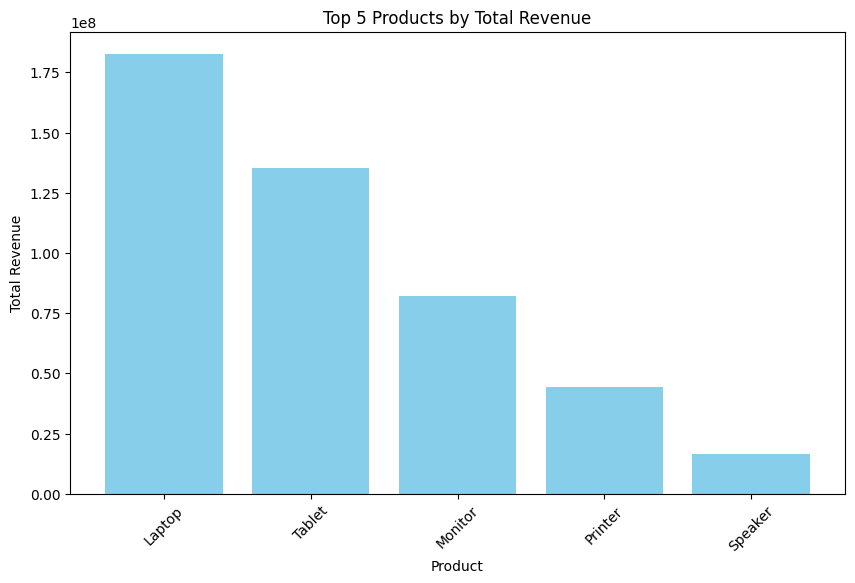

In [7]:
plt.figure(figsize=(10, 6))
plt.bar(top_products_df['product'], top_products_df['total_revenue'], color='skyblue')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.title('Top 5 Products by Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [16]:
# ETL (Extract, Transform, Load)

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
order_id          0
customer_name     0
product           0
category          0
quantity          0
unit_price        0
revenue           0
order_date        0
city              0
region            0
sales_rep         0
payment_method    0
order_status      0
dtype: int64


In [18]:
print("Duplicate Values: ")
print(df.duplicated().sum())

Duplicate Values: 
0


In [23]:
# Converting order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Extracting Month and Year from order_date
df['order_month'] = df['order_date'].dt.month_name()
df['order_year'] = df['order_date'].dt.year

# Creating a high-value order flag (revenue > 100,000)
df['is_high_value'] = df['revenue'] > 100000

print("=" * 60)
print("ETL Transformations Applied:")
print("=" * 60)
print(df[['order_date', 'order_month', 'order_year', 'is_high_value']].head())
print()
print(df.describe())
print()
print("*" * 60)
print("New Transfrmed DataFrame")
print("*" * 60)
print(df.head(10))

ETL Transformations Applied:
  order_date order_month  order_year  is_high_value
0 2023-05-21         May        2023           True
1 2023-08-05      August        2023           True
2 2023-01-14     January        2023          False
3 2023-01-04     January        2023           True
4 2023-06-22        June        2023          False

          order_id     quantity    unit_price        revenue  \
count  5000.000000  5000.000000   5000.000000    5000.000000   
mean   3500.500000     7.953600  12496.860000   99169.520000   
min    1001.000000     1.000000    600.000000     600.000000   
25%    2250.750000     4.000000   1200.000000    8800.000000   
50%    3500.500000     8.000000   3500.000000   30000.000000   
75%    4750.250000    12.000000  22000.000000  132000.000000   
max    6000.000000    15.000000  45000.000000  675000.000000   
std    1443.520003     4.275313  14857.384309  145972.971953   

                       order_date  order_year  
count                        5000

In [26]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType
import random

# Initialize Spark Session
spark = SparkSession.builder.appName("MedallionPipeline").getOrCreate()

# 1. Generate Sample Data (50 rows)
products = ['Laptop', 'Tablet', 'Monitor', 'Printer', 'Speaker', 'Mouse', 'Keyboard']
categories = ['Electronics', 'Accessories']
regions = ['North', 'South', 'East', 'West']

data = []
for i in range(1, 51):
    data.append((
        1000 + i,
        f"Customer_{i}",
        random.choice(products),
        random.choice(categories),
        random.randint(1, 10),
        float(random.randint(500, 50000)),
        "2023-12-01",
        random.choice(regions)
    ))

schema = StructType([
    StructField("order_id", IntegerType(), True),
    StructField("customer_name", StringType(), True),
    StructField("product", StringType(), True),
    StructField("category", StringType(), True),
    StructField("quantity", IntegerType(), True),
    StructField("unit_price", FloatType(), True),
    StructField("order_date", StringType(), True),
    StructField("region", StringType(), True)
])

# Bronze Layer: Raw Data
df_bronze = spark.createDataFrame(data, schema)
print("Bronze Layer Created (Sample 50 rows):")
df_bronze.show(5)

Bronze Layer Created (Sample 50 rows):
+--------+-------------+-------+-----------+--------+----------+----------+------+
|order_id|customer_name|product|   category|quantity|unit_price|order_date|region|
+--------+-------------+-------+-----------+--------+----------+----------+------+
|    1001|   Customer_1|Printer|Accessories|       3|   18914.0|2023-12-01|  East|
|    1002|   Customer_2|Monitor|Accessories|       2|   44645.0|2023-12-01| South|
|    1003|   Customer_3|Printer|Accessories|       5|   22893.0|2023-12-01| North|
|    1004|   Customer_4| Tablet|Electronics|       4|   11067.0|2023-12-01|  West|
|    1005|   Customer_5| Tablet|Electronics|       3|    1710.0|2023-12-01|  West|
+--------+-------------+-------+-----------+--------+----------+----------+------+
only showing top 5 rows


### Medallion Architecture: Silver Layer
In this step, we transform the Bronze data into the Silver layer by calculating revenue and cleaning types.

In [27]:
# Silver Layer: Cleaned and Augmented
df_silver = df_bronze.withColumn("revenue", F.col("quantity") * F.col("unit_price")) \
                     .withColumn("order_date", F.to_date(F.col("order_date")))

print("Silver Layer (Transformed Data):")
df_silver.show(5)

Silver Layer (Transformed Data):
+--------+-------------+-------+-----------+--------+----------+----------+------+--------+
|order_id|customer_name|product|   category|quantity|unit_price|order_date|region| revenue|
+--------+-------------+-------+-----------+--------+----------+----------+------+--------+
|    1001|   Customer_1|Printer|Accessories|       3|   18914.0|2023-12-01|  East| 56742.0|
|    1002|   Customer_2|Monitor|Accessories|       2|   44645.0|2023-12-01| South| 89290.0|
|    1003|   Customer_3|Printer|Accessories|       5|   22893.0|2023-12-01| North|114465.0|
|    1004|   Customer_4| Tablet|Electronics|       4|   11067.0|2023-12-01|  West| 44268.0|
|    1005|   Customer_5| Tablet|Electronics|       3|    1710.0|2023-12-01|  West|  5130.0|
+--------+-------------+-------+-----------+--------+----------+----------+------+--------+
only showing top 5 rows


### Medallion Architecture: Gold Layer
Aggregating total revenue by product and category for business reporting.

In [32]:
# Gold Layer: Aggregations
df_gold = df_silver.groupBy("category", "product").agg(F.sum("revenue").alias("total_revenue"))

print("Gold Layer (Business Insights):")
df_gold.orderBy(F.desc("total_revenue")).show(5)

Gold Layer (Business Insights):
+-----------+-------+-------------+
|   category|product|total_revenue|
+-----------+-------+-------------+
|Accessories|Printer|    1063331.0|
|Accessories|  Mouse|     926616.0|
|Electronics|Speaker|     894955.0|
|Accessories| Laptop|     890590.0|
|Electronics|  Mouse|     677194.0|
+-----------+-------+-------------+
only showing top 5 rows


### RAG Implementation
Using SentenceTransformers for embeddings and ChromaDB as the vector store.

In [33]:
import chromadb
from sentence_transformers import SentenceTransformer

# Initialize the embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Initialize ChromaDB client
chroma_client = chromadb.Client()
try:
    collection = chroma_client.create_collection(name="product_knowledge_base")
except:
    collection = chroma_client.get_collection(name="product_knowledge_base")

# Prepare data for RAG
pandat_gold = df_gold.toPandas()
texts = [
    f"Product {row['product']} in category {row['category']} has a total revenue of {row['total_revenue']}"
    for _, row in pandat_gold.iterrows()
]
ids = [str(i) for i in range(len(texts))]

# Generate embeddings and add to collection
embeddings = model.encode(texts).tolist()
collection.add(
    embeddings=embeddings,
    documents=texts,
    ids=ids
)

print(f"Successfully indexed {len(texts)} documents in ChromaDB.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Successfully indexed 14 documents in ChromaDB.


In [39]:
# Demonstrate RAG: Semantic query against the indexed Gold data
user_query = "Which product has the highest total revenue?"
query_embedding = model.encode([user_query]).tolist()

# Query ChromaDB
results = collection.query(
    query_embeddings=query_embedding,
    n_results=1
)

print(f"User Query: {user_query}")
print(f"Top Retrieved Insight: {results['documents'][0][0]}")

User Query: Which product has the highest total revenue?
Top Retrieved Insight: Product Tablet in category Accessories has a total revenue of 159048.0


In [38]:
# Demonstrate RAG: Semantic query against the indexed Gold data
user_query = "Which product in the Accessories category has the highest revenue?"
query_embedding = model.encode([user_query]).tolist()

# Query ChromaDB
results = collection.query(
    query_embeddings=query_embedding,
    n_results=1
)

print(f"User Query: {user_query}")
print(f"Top Retrieved Insight: {results['documents'][0][0]}")

User Query: Which product in the Accessories category has the highest revenue?
Top Retrieved Insight: Product Monitor in category Accessories has a total revenue of 484054.0


In [37]:
# Demonstrate RAG: Semantic query against the indexed Gold data
user_query = "Which product in the Accessories category has the highest revenue?"
query_embedding = model.encode([user_query]).tolist()

# Query ChromaDB
results = collection.query(
    query_embeddings=query_embedding,
    n_results=1
)

print(f"User Query: {user_query}")
print(f"Top Retrieved Insight: {results['documents'][0][0]}")

User Query: Which product in the Accessories category has the highest revenue?
Top Retrieved Insight: Product Monitor in category Accessories has a total revenue of 484054.0


In [36]:
# Demonstrate RAG: Semantic query against the indexed Gold data
user_query = "Which product in the Accessories category has the highest revenue?"
query_embedding = model.encode([user_query]).tolist()

# Query ChromaDB
results = collection.query(
    query_embeddings=query_embedding,
    n_results=1
)

print(f"User Query: {user_query}")
print(f"Top Retrieved Insight: {results['documents'][0][0]}")

User Query: Which product in the Accessories category has the highest revenue?
Top Retrieved Insight: Product Monitor in category Accessories has a total revenue of 484054.0


In [35]:
# Demonstrate RAG: Semantic query against the indexed Gold data
user_query = "Which product in the Accessories category has the highest revenue?"
query_embedding = model.encode([user_query]).tolist()

# Query ChromaDB
results = collection.query(
    query_embeddings=query_embedding,
    n_results=1
)

print(f"User Query: {user_query}")
print(f"Top Retrieved Insight: {results['documents'][0][0]}")

User Query: Which product in the Accessories category has the highest revenue?
Top Retrieved Insight: Product Monitor in category Accessories has a total revenue of 484054.0


In [34]:
# Demonstrate RAG: Querying the Knowledge Base
query_text = "Which product in the Accessories category has the highest revenue?"
query_embedding = model.encode([query_text]).tolist()

results = collection.query(
    query_embeddings=query_embedding,
    n_results=1
)

print(f"User Query: {query_text}")
print(f"Retrieved Insight: {results['documents'][0][0]}")

User Query: Which product in the Accessories category has the highest revenue?
Retrieved Insight: Product Monitor in category Accessories has a total revenue of 484054.0


### Medallion Architecture: Gold Layer
Aggregating total revenue by product and category for business reporting.

In [30]:
# Gold Layer: Aggregations
df_gold = df_silver.groupBy("category", "product").agg(F.sum("revenue").alias("total_revenue"))

print("Gold Layer (Business Insights):")
df_gold.orderBy(F.desc("total_revenue")).show(5)

Gold Layer (Business Insights):
+-----------+-------+-------------+
|   category|product|total_revenue|
+-----------+-------+-------------+
|Accessories|Printer|    1063331.0|
|Accessories|  Mouse|     926616.0|
|Electronics|Speaker|     894955.0|
|Accessories| Laptop|     890590.0|
|Electronics|  Mouse|     677194.0|
+-----------+-------+-------------+
only showing top 5 rows


### RAG Implementation
Using SentenceTransformers for embeddings and ChromaDB as the vector store.

In [31]:
import chromadb
from sentence_transformers import SentenceTransformer

# Initialize the embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Initialize ChromaDB client
chroma_client = chromadb.Client()
try:
    collection = chroma_client.create_collection(name="product_knowledge_base")
except:
    collection = chroma_client.get_collection(name="product_knowledge_base")

# Prepare data for RAG
pandat_gold = df_gold.toPandas()
texts = [
    f"Product {row['product']} in category {row['category']} has a total revenue of {row['total_revenue']}"
    for _, row in pandat_gold.iterrows()
]
ids = [str(i) for i in range(len(texts))]

# Generate embeddings and add to collection
embeddings = model.encode(texts).tolist()
collection.add(
    embeddings=embeddings,
    documents=texts,
    ids=ids
)

print(f"Successfully indexed {len(texts)} documents in ChromaDB.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Successfully indexed 14 documents in ChromaDB.


### Medallion Architecture: Gold Layer
Aggregating total revenue by product and category for business reporting.

In [28]:
# Gold Layer: Aggregations
df_gold = df_silver.groupBy("category", "product").agg(F.sum("revenue").alias("total_revenue"))

print("Gold Layer (Business Insights):")
df_gold.orderBy(F.desc("total_revenue")).show(5)

Gold Layer (Business Insights):
+-----------+-------+-------------+
|   category|product|total_revenue|
+-----------+-------+-------------+
|Accessories|Printer|    1063331.0|
|Accessories|  Mouse|     926616.0|
|Electronics|Speaker|     894955.0|
|Accessories| Laptop|     890590.0|
|Electronics|  Mouse|     677194.0|
+-----------+-------+-------------+
only showing top 5 rows


### RAG Implementation
Using SentenceTransformers for embeddings and ChromaDB as the vector store.

In [29]:
import chromadb
from sentence_transformers import SentenceTransformer

# Initialize the embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Initialize ChromaDB client
chroma_client = chromadb.Client()
collection = chroma_client.create_collection(name="product_knowledge_base")

# Prepare data for RAG
# We'll create a simple text representation for each row in the Gold layer
pandat_gold = df_gold.toPandas()
texts = [
    f"Product {row['product']} in category {row['category']} has a total revenue of {row['total_revenue']}"
    for _, row in pandat_gold.iterrows()
]
ids = [str(i) for i in range(len(texts))]

# Generate embeddings and add to collection
embeddings = model.encode(texts).tolist()
collection.add(
    embeddings=embeddings,
    documents=texts,
    ids=ids
)

print(f"Successfully indexed {len(texts)} documents in ChromaDB.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Successfully indexed 14 documents in ChromaDB.


# **Machine Learning (Revenue Prediction for the Sales)**

In [40]:
#=================================================
# Get the Current Total Revenue of the Sales Made
#=================================================

total_revenue = df['revenue'].sum()
print("=" * 60)
print(f"Total Current Revenue: ${total_revenue:.2f}")
print("=" * 60)


Total Current Revenue: $495847600.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted Total Revenue for January 2024: $45,608,478.10


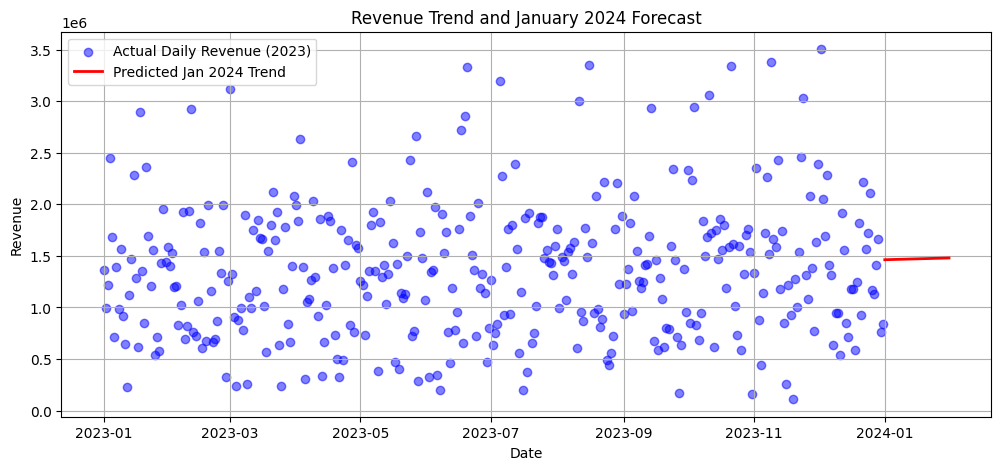

In [44]:
#======================================================
# Predicting the Total Revenue for January 2024
#======================================================
from sklearn.linear_model import LinearRegression
import datetime as dt

# Preparing historical daily revenue data
daily_revenue = df.groupby('order_date')['revenue'].sum().reset_index()
daily_revenue['date_ordinal'] = daily_revenue['order_date'].map(dt.datetime.toordinal)

# Training a Linear Regression Model
X = daily_revenue[['date_ordinal']]
y = daily_revenue['revenue']
model_lr = LinearRegression()
model_lr.fit(X, y)

# Creating a range of dates for January 2024
jan_2024_dates = pd.date_range(start='2024-01-01', end='2024-01-31')
jan_2024_ordinals = np.array([d.toordinal() for d in jan_2024_dates]).reshape(-1, 1)

# Predicting daily revenue and calculate monthly total
predicted_daily_revenue = model_lr.predict(jan_2024_ordinals)
predicted_jan_total = predicted_daily_revenue.sum()

print("=" * 60)
print(f"Predicted Total Revenue for January 2024: ${predicted_jan_total:,.2f}")
print("=" * 60)

# Visualization of the trend
plt.figure(figsize=(12, 5))
plt.scatter(daily_revenue['order_date'], daily_revenue['revenue'], color='blue', alpha=0.5, label='Actual Daily Revenue (2023)')
plt.plot(jan_2024_dates, predicted_daily_revenue, color='red', linewidth=2, label='Predicted Jan 2024 Trend')
plt.title('Revenue Trend and January 2024 Forecast')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()